## T5: Isolated Tip
For this tuturial we proceed as before, with the exeption that we use a so-called realspace selfenergy, meaning we can model a single point in real space in a periodic slab. We utilize a particular calculator from sisl. In particular, we'll model a in contact with a sheet of graphene. For this purpose we will get more manual in the construction of the Hamiltonians needed and run some calculations manually, because they are not implented in a nice program yet. We now also use explicitly use the siesta_python code, which has been running in the background previously. The code for this is largely reused from the sisl-tutorial on this same topic. 

dep:0: SislDeprecation: SuperCell is deprecated; please use 'Lattice' class instead [>=0.15] [removed in 0.16]
dep:0: SislDeprecation: __init__ argument sc has been deprecated in favor of lattice, please update your code. [>=0.15] [removed in 0.16]
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_lattice']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_positions']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_types']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/p

[[0, 3, 4, 7, 8, 11, 12, 23, 24, 25, 26, 29, 30, 33, 34, 35], [np.int64(36), np.int64(37), np.int64(38)]]
Running TB-Trans in Directory: Device!

Normal plot


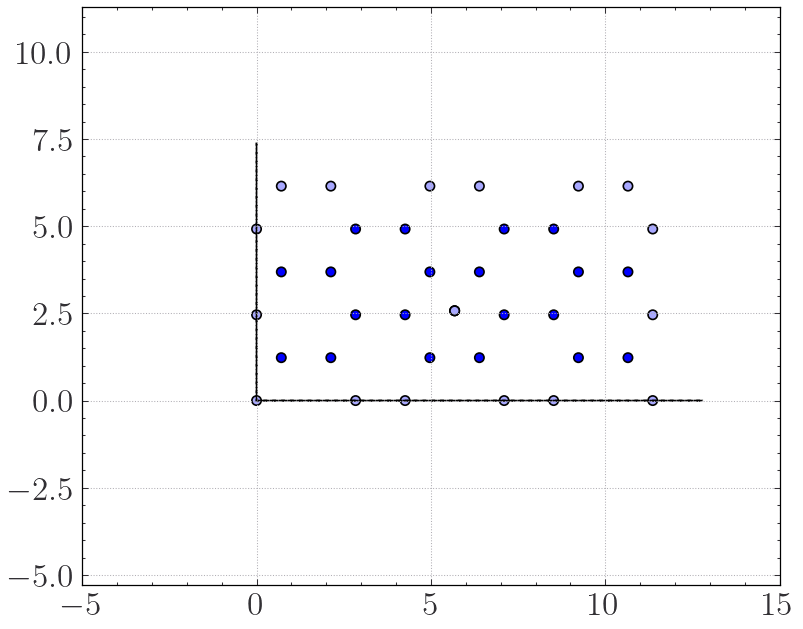

warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].

---> Hello! <--- 
It seems like you have used the a real-space self energy! good for you.
This does however mean you need to compute a  rigid shift in the energy-levels in the Hamiltonian!
This is done using the self.Renormalise_H and the find_correction from fitting tools.
This should be covered in a tutorial.
 ----><----
Calculating corrections for electrode 0. (RSSE electrode)
Calculating corrections for electrode 1. (Normal electrode)

 Building ES - H - Self Energies 

[0]
Using S = S

 Overlap Included!



In [1]:
import sisl
import numpy as np
from Zandpack.TimedependentTransport import TD_Transport
from siesta_python.siesta_python import SiP
import matplotlib.pyplot as plt
#  sisl geometries:
t1,t2 = 3,3
graphene = sisl.geom.graphene(orthogonal=True)
slab = graphene.tile(t1,0).tile(t2,1)

STM = sisl.Geometry([0, 0, 1], atoms=sisl.Atom('Au', R=1.0001), sc=sisl.SuperCell([10, 10, 1], nsc=[1, 1, 3]))
STM = STM.tile(3,2).move(slab.center() + np.array([0,-0.5, -1]))
tip = STM.tile(1,2)

geom_dev = slab.add(tip)
geom_dev = geom_dev.add_vacuum(40,2)
R  = TD_Transport ([graphene, tip],  geom_dev)
line = np.linspace(-5,5,20)+1j*1e-2
line = np.vstack([line]*2)
R.Make_Contour(line, 15, pole_mode = 'JieHu2011')


# Objects to run tbtrans from:
elec_RS = SiP(graphene.cell,graphene.xyz, graphene.atoms.Z,
             basis = 'SZ', pp_path = '../pp',
             semi_inf='ab',mpi = '',
             directory_name = 'C',sl = 'C', sm = 'C',
             dm_tol = '1.d-6', kp = [20, 20, 1],
             overwrite = True,
             elec_RSSE = True)

stm    = SiP(STM.cell, STM.xyz, STM.atoms.Z,
             basis = 'SZ', pp_path = '../pp', mpi = '',
             semi_inf = '+a3', directory_name = 'Au_tip', sl = 'Au_tip', sm = 'Au_tip',
             dm_tol = '1.d-6', kp = [1,1,20],
             overwrite = True)

Dev    = SiP(geom_dev.cell, geom_dev.xyz, geom_dev.atoms.Z,
             solution_method = 'transiesta',
             basis = 'SZ', pp_path = '../pp',mpi = '',
             directory_name = 'Device', elecs = [elec_RS, stm],
             kp_tbtrans = [1,1,1],
             dm_tol = '1.d-4', kp = [1,1,1],Chem_Pot = [0.0, 0.0],
             overwrite = True, save_SE=True, custom_tbtrans_contour=R.Contour
            )

# Electronic structure
H_grph = sisl.Hamiltonian(graphene)
H_grph.construct([[0.0, 1.45],[0.0, -2.7]])
H_stm = sisl.Hamiltonian(STM)
H_stm.construct([[0.0, 1.45],[0.0, -2.7]])
# Circumvent TranSiesta
elec_RS.fois_gras(H_grph)
stm    .fois_gras(H_stm)
elec_RS.fdf()
stm    .fdf()
# Run realspace calculation for graphene sheet
elec_RS.Real_space_SE(0,1,(t1,t2,1), 0.0, -0, 0, 2/50, Contour = R.Contour, 
                      parallel_E = True, num_procs=4)
Dev.find_elec_inds()
# Electronic structure of Device & TBtrans calculation
H_dev = sisl.Hamiltonian(Dev.to_sisl())
H_dev.construct([[0.0, 1.45],[0.0, -2.7]])
Dev.fois_gras(H_dev)
Dev.fdf()
Dev.run_tbtrans_in_dir()
plt.show()
Dev.Visualise()

plt.show()
plt.pause(0.1); 
# We give our TD calculator object this device object and we can proceed as usual:
R.Device = Dev
R.read_data()



In [2]:
# R.reset_all_fits()
def run_mini(its):
    R.Fit(fact = 0.5,  NumL = 12,
          fit_mode = 'all',
              min_method='trust-constr',
              ebounds = (-5.1, 5.1), 
              wbounds = (0.01, 20.0), 
              gbounds = (None, None),
              tol = -1, 
              options = {'disp':True,
                         'maxiter':its, 
                         #'gtol':1e-5, 
                         #'ftol':1e-5, 
                         #'iprint':1
                         },
              fit_real_part = False,
              specific_bounds = None, 
              alpha_PO = 0.1,
              cons = '')


In [3]:
#help(R.Fit)
run_mini(100)

Finding Lambda matrices:
False

--------------------
Optimizing Lorentzian Expansion
--------------------

20
#Variables optimized for: 24
F,it =  278.62038, 4
F,it =  251.90416, 8
F,it =  245.9465, 12
F,it =  244.56981, 16
F,it =  244.49266, 20
F,it =  244.44851, 24
F,it =  243.98623, 28
F,it =  243.8811, 32
F,it =  243.84168, 36
F,it =  243.84003, 40
F,it =  243.82113, 44
F,it =  243.8079, 48
F,it =  243.79295, 52
F,it =  243.78182, 56
F,it =  243.77372, 60
F,it =  243.76817, 64
F,it =  243.76513, 68
F,it =  243.76413, 72
F,it =  243.76315, 76
F,it =  243.76315, 80
F,it =  243.76315, 84
F,it =  243.76315, 88
F,it =  243.76315, 92
F,it =  243.76315, 96
F,it =  243.76315, 100
The maximum number of function evaluations is exceeded.
Number of iterations: 100, function evaluations: 139, CG iterations: 375, optimality: 1.41e+01, constraint violation: 0.00e+00, execution time:  2.2 s.
Lorentzian fit took 13.032363414764404 seconds.
Finding Lambda matrices:
False

--------------------
Optimi

/home/investigator/Desktop/Code/PythonModules/Zandpack/Zandpack/TimedependentTransport.py:1613: RuntimeWarning: divide by zero encountered in scalar divide
  width = min(np.abs(xr-x)*np.sqrt(yr)/(np.sqrt(1-np.abs(yr))) ,


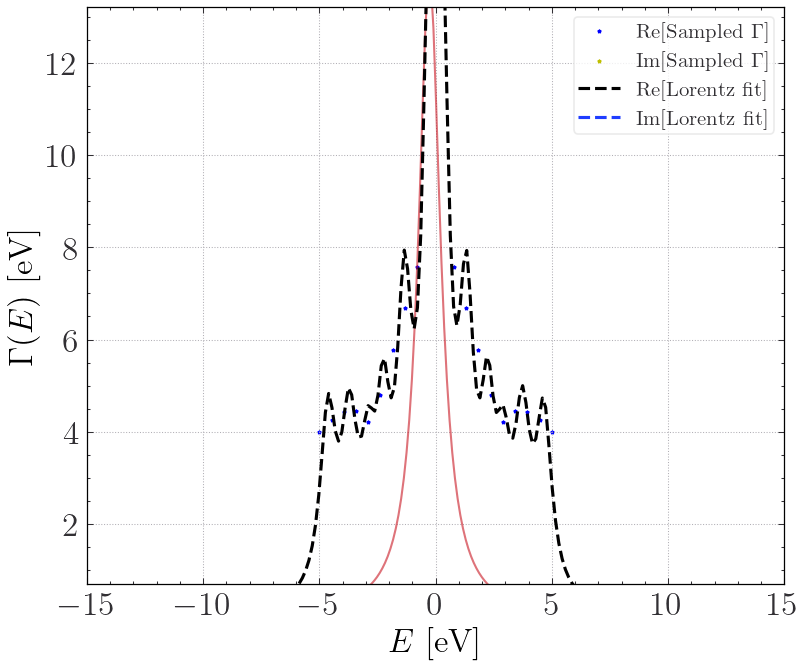

Minimum distance from Fermi-poles to Lorentzian poles: 0.29483258601313767/n
Minimum distance between Lorentzian poles: 0.5906375322469641/n
Minimum value of imaginary part of Lorentzian poles: 0.3120051947854665


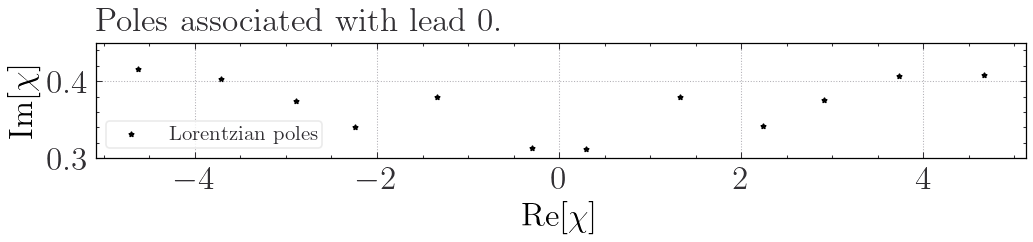

In [7]:
R.Inspect_Lorentzian_fit(0, 0,0,0,0, Emin = -7, Emax = 7)
plt.show()
R.Inspect_Poles(0, fermi_poles=False)


In [8]:
R.fitted_lorentzians[1].is_zero

array([[0, 0],
       [0, 1]])

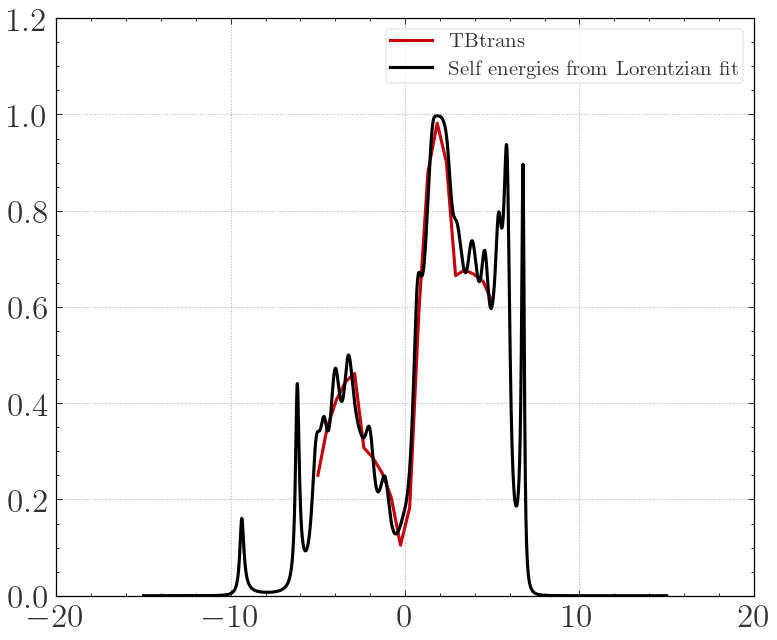

In [9]:
R.Inspect_transmission_from_hilbert_transform(eta = 1e-3, E = np.linspace(-15,15,1800)) 

In [24]:
R.tofile('RSSE')

Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 31.071855
Minimum of eigenvalues of Lorentzian Gammas: -0.0
If the minimum is negative, you should take extra care!
( if minimum negative Check eigenvalues of $\Gamma$)


In [ ]:
!SCF Dir=$PWD file=RSSE
!psinought Dir=$PWD file=RSSE
!mpirun -np 3 SuperZand Dir=$PWD


SCF Program Start

sys.argv: ['/home/aleksander/Desktop/Input_hpc_master/PythonModules/Zandpack/Zandpack/cmdtools/SCF', 'Dir=/home/aleksander/Desktop/TDtut_updated/TightBinding/T5:IsolatedTip', 'file=RSSE']

----> Mu =  [0. 0.]
----> Bias=  [ 0. -0.]
Contour-file:   /home/aleksander/Desktop/Input_hpc_master/PythonModules/Zandpack/Zandpack/cmdtools/SCF_default_Contour.npy
2
Evaluating SEs
Done
Iteration  1 | dN_max:   0.000994 | Qtot_k [9.827348+0.j]
Iteration  2 | dN_max:   0.000298 | Qtot_k [9.824354+0.j]
Iteration  3 | dN_max:   0.0 | Qtot_k [9.824354+0.j]
psinought Program Start

sys.argv: ['/home/aleksander/Desktop/Input_hpc_master/PythonModules/Zandpack/Zandpack/cmdtools/psinought', 'Dir=/home/aleksander/Desktop/TDtut_updated/TightBinding/T5:IsolatedTip', 'file=RSSE']

psinought: Reading arrays.....
DM input from  RSSE/Arrays/DM_Ortho.npy
psinought: Converging steady-state with DM from     RSSE/Arrays/   folder.
psinought: Particle number:  [9.82435359+0.j]
psinought: Bias:       

t=-97.742 | #steps=50 | eps=6.654e-07
    Bias_0: 0.0   | J_0: -1.1e-05| Total: -1.1e-05
    Bias_1: -0.0   | J_1: -1.3e-05| Total: -1.3e-05
t=-95.741 | #steps=100 | eps=5.972e-07
    Bias_0: 0.0   | J_0: -5.e-06| Total: -5e-06
    Bias_1: -0.0   | J_1: 5.8e-05| Total: 5.8e-05
t=-93.74 | #steps=150 | eps=5.886e-07
    Bias_0: 0.0   | J_0: -8.e-06| Total: -8e-06
    Bias_1: -0.0   | J_1: -1.5e-05| Total: -1.5e-05
t=-91.739 | #steps=200 | eps=5.902e-07
    Bias_0: 0.0   | J_0: -1.e-06| Total: -1e-06
    Bias_1: -0.0   | J_1: -1.3e-05| Total: -1.3e-05
t=-89.738 | #steps=250 | eps=5.908e-07
    Bias_0: 0.0   | J_0: 1.e-06| Total: 1e-06
    Bias_1: -0.0   | J_1: 7.e-06| Total: 7e-06
t=-87.737 | #steps=300 | eps=5.903e-07
    Bias_0: 0.0   | J_0: -0.| Total: -0.0
    Bias_1: -0.0   | J_1: 4.e-06| Total: 4e-06
t=-85.737 | #steps=350 | eps=5.906e-07
    Bias_0: 0.0   | J_0: -1.e-06| Total: -1e-06
    Bias_1: -0.0   | J_1: -0.| Total: -0.0
t=-83.736 | #steps=400 | eps=5.906e-07
    Bias_0: 0.0 

In [ ]:
!td_info Dir=$PWD file=RSSE plotcurrent=1 label=Current format=png
im = img.imread('CurrentCurrentplot.png')
plt.rcParams['figure.figsize']=(15,9)
plt.imshow(im)


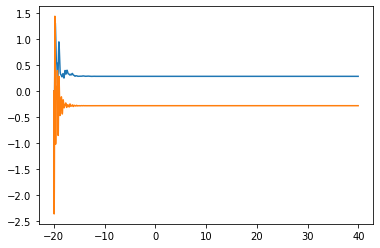

In [107]:
plt.plot(t2, data2['current_left'])
plt.plot(t2, data2['current_right'])



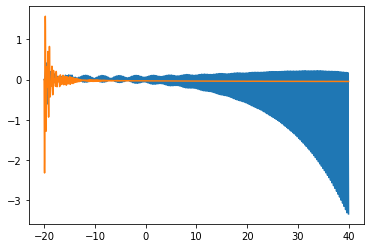

In [46]:
plt.plot(t2, data2['current_left'])
plt.plot(t2, data2['current_right'])


In [205]:
dir(R)

['BS',
 'BTD_overlap',
 'Check_input_to_ODE',
 'Contour',
 'Device',
 'E_F',
 'Electrodes',
 'F_poles',
 'F_poles_idx',
 'Fit',
 'GG_M',
 'GG_P',
 'GL_M',
 'GL_P',
 'Get_DOS',
 'Gl_eig',
 'Gl_vec',
 'Gp_eig',
 'Gp_vec',
 'Hdense',
 'Inspect_Lorentzian_fit',
 'Inspect_Poles',
 'Inspect_SE_lorentzian_fit',
 'Inspect_Transmission',
 'Inspect_transmission_from_SE_fit',
 'Inv_Gp_vec',
 'Ixi',
 'Ldense',
 'Lorentzian_centers',
 'Lowdin',
 'Make_Contour',
 'NO_DM',
 'N_L',
 'Nonortho_Gammas',
 'Nonortho_Hamiltonian',
 'Nonortho_iG',
 'NumL',
 'Ortho_Gammas',
 'Ortho_Hamiltonian',
 'Psi_vec',
 'Xpm',
 'Xpp',
 '_Inv_Gl_vec',
 '_Slices',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakre

In [8]:
help(elec_RS.Real_space_SE)

Help on method Real_space_SE in module siesta_python.siesta_python:

Real_space_SE(ax_decimation, ax_integrate, supercell, eta, Emin, Emax, dE, Contour=None, ending='TSHS', only_couplings=False, dk=1000.0, mu=None, parallel_E=False, num_procs=4, write_to_tbtrans=True) method of siesta_python.siesta_python.SiP instance
    Straight out of sisl tutorial TB8
    see sisl documentation RealSpaceSE for more
    info

